In [2]:
import matplotlib.pylab as pylab
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from src import *

set_fonts()

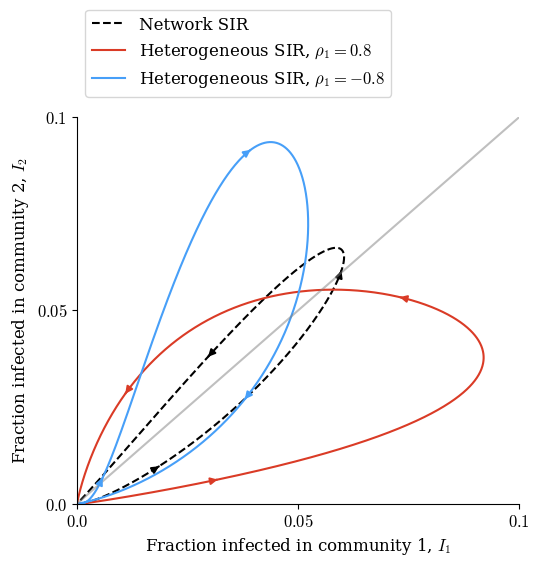

In [ ]:
colors = sns.color_palette("blend:#479FF8,#DA3B26", n_colors=5)

k = 10
R0 = 1.5
gam = 0.1

eps = np.linspace(0, 3, 100)
dels = np.linspace(0, 3, 100)

beta = IBC_beta(
    eps @ create_comm(0.8) @ dels,
    eps @ create_comm(-0.8) @ dels,
    R0,
    gam,
    k,
    e=0,
    r=0.5,
)

P = {"beta": beta, "gamma": gam, "k": k, "e": 0.9, "r": 0.5}

# Initial SIR frequencies
P["S1"] = 1.0 * np.ones((100, 100))
P["I1"] = 0.0 * np.ones((100, 100))
P["R1"] = 0.0 * np.ones((100, 100))
P["S2"] = 1.0 * np.ones((100, 100))
P["I2"] = 0.0 * np.ones((100, 100))
P["R2"] = 0.0 * np.ones((100, 100))

# Seeding comm 1,
sim1 = P.copy()
sim1["S1"] = 0.999 * np.ones((100, 100))
sim1["I1"] = 0.001 * np.ones((100, 100))
sim1["R1"] = 0.00 * np.ones((100, 100))

# Seeding comm 2,
sim2 = P.copy()
sim2["S1"] = 0.999 * np.ones((100, 100))
sim2["I1"] = 0.001 * np.ones((100, 100))
sim2["R1"] = 0.00 * np.ones((100, 100))

# Basic SIR model with no heterogeneity
basic_P1 = P.copy()
basic_P1["S1"] = 0.999
basic_P1["I1"] = 0.001
basic_P1["R1"] = 0.00
basic_P1["S2"] = 1.0
basic_P1["I2"] = 0.00
basic_P1["R2"] = 0.00

basic_P1["beta"] = R0 * gam / k

rep_tmp1 = []
rep_tmp2 = []
rep_tmp_SIR1 = []
for i, rho in enumerate([0.8]):  # np.linspace(0, 0.8, 3)):

    # The distributions for the two communities
    sim1["g1"] = create_comm(rho)
    sim1["g2"] = create_comm(-rho)
    sim2["g1"] = create_comm(-rho)
    sim2["g2"] = create_comm(rho)

    results1 = network_model_communities(sim1, 500, 0.1)
    results2 = network_model_communities(sim2, 500, 0.1)
    results_SIR1 = network_SIR_homogeneous(basic_P1, 500, 0.1)

    I1_tmp1 = results1[1]
    I2_tmp1 = results1[4]

    I1_tmp2 = results2[1]
    I2_tmp2 = results2[4]

    I1_SIR_tmp1 = results_SIR1[1]
    I2_SIR_tmp1 = results_SIR1[4]

    rep_tmp1.append((I1_tmp1, I2_tmp1))
    rep_tmp2.append((I1_tmp2, I2_tmp2))

    rep_tmp_SIR1.append((I1_SIR_tmp1, I2_SIR_tmp1))

plt.figure(figsize=(5.5, 6))

plt.plot(
    rep_tmp_SIR1[0][0],
    rep_tmp_SIR1[0][1],
    label=r"Network SIR",
    color="black",
    linestyle="--",
)
plt.annotate(
    "",
    xy=(rep_tmp_SIR1[0][0][701], rep_tmp_SIR1[0][1][701]),
    xytext=(rep_tmp_SIR1[0][0][700], rep_tmp_SIR1[0][1][700]),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1.5),
    zorder=0,
)
plt.annotate(
    "",
    xy=(rep_tmp_SIR1[0][0][1201], rep_tmp_SIR1[0][1][1201]),
    xytext=(rep_tmp_SIR1[0][0][1200], rep_tmp_SIR1[0][1][1200]),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1.5),
    zorder=0,
)
plt.annotate(
    "",
    xy=(rep_tmp_SIR1[0][0][1701], rep_tmp_SIR1[0][1][1701]),
    xytext=(rep_tmp_SIR1[0][0][1700], rep_tmp_SIR1[0][1][1700]),
    arrowprops=dict(arrowstyle="-|>", color="black", linewidth=1.5),
    zorder=0,
)
plt.plot(
    rep_tmp1[0][0],
    rep_tmp1[0][1],
    label=rf"Heterogeneous SIR, $\rho_1 = {rho}$",
    color=colors[-1],
)
plt.annotate(
    "",
    xy=(rep_tmp1[0][0][501], rep_tmp1[0][1][501]),
    xytext=(rep_tmp1[0][0][500], rep_tmp1[0][1][500]),
    arrowprops=dict(arrowstyle="-|>", color=colors[-1], linewidth=1.5),
    zorder=10,
)
plt.annotate(
    "",
    xy=(rep_tmp1[0][0][1001], rep_tmp1[0][1][1001]),
    xytext=(rep_tmp1[0][0][1000], rep_tmp1[0][1][1000]),
    arrowprops=dict(arrowstyle="-|>", color=colors[-1], linewidth=1.5),
    zorder=10,
)
plt.annotate(
    "",
    xy=(rep_tmp1[0][0][1501], rep_tmp1[0][1][1501]),
    xytext=(rep_tmp1[0][0][1500], rep_tmp1[0][1][1500]),
    arrowprops=dict(arrowstyle="-|>", color=colors[-1], linewidth=1.5),
    zorder=10,
)
plt.plot(
    rep_tmp2[0][0],
    rep_tmp2[0][1],
    label=rf"Heterogeneous SIR, $\rho_1 = {-rho}$",
    color=colors[0],
)
plt.annotate(
    "",
    xy=(rep_tmp2[0][0][501], rep_tmp2[0][1][501]),
    xytext=(rep_tmp2[0][0][500], rep_tmp2[0][1][500]),
    arrowprops=dict(arrowstyle="-|>", color=colors[0], linewidth=1.5),
    zorder=10,
)
plt.annotate(
    "",
    xy=(rep_tmp2[0][0][1001], rep_tmp2[0][1][1001]),
    xytext=(rep_tmp2[0][0][1000], rep_tmp2[0][1][1000]),
    arrowprops=dict(arrowstyle="-|>", color=colors[0], linewidth=1.5),
    zorder=10,
)
plt.annotate(
    "",
    xy=(rep_tmp2[0][0][1501], rep_tmp2[0][1][1501]),
    xytext=(rep_tmp2[0][0][1500], rep_tmp2[0][1][1500]),
    arrowprops=dict(arrowstyle="-|>", color=colors[0], linewidth=1.5),
    zorder=10,
)

plt.legend(loc="upper left", bbox_to_anchor=(0, 1.3))
plt.xlabel(r"Fraction infected in community 1, $I_1$")
plt.ylabel(r"Fraction infected in community 2, $I_2$")

x = np.linspace(0, 0.1, 100)
y = x
plt.plot(x, y, color="grey", alpha=0.5)

plt.xticks([0.0, 0.05, 0.1], [r"$0.0$", r"$0.05$", r"$0.1$"])
plt.yticks([0.0, 0.05, 0.1], [r"$0.0$", r"$0.05$", r"$0.1$"])

plt.xlim(0, 0.1)
plt.ylim(0, 0.1)

sns.despine()

plt.tight_layout()

plt.savefig("Figures/Figure-4.png", dpi=1000, bbox_inches="tight")
plt.savefig("Figures/Figure-4.svg", format="svg", bbox_inches="tight")
plt.savefig("Figures/Figure-4.pdf", format="pdf", bbox_inches="tight")